# Inventory en ObsPy

## Índice
1. [Introducción](#1-introducción)
2. [Visualización de un Inventory](#2-visualizar)
3. [Extracción de información de un Inventory](#3-información)
4. [Selección de datos](#4-selección-de-datos)
5. [Escritura de un Inventory](#5-escritura)
6. [Uso de Inventory con datos sísmicos](#6-uso-con-datos)

## 1. Introducción a Inventory en ObsPy <a id="1-introducción"></a>
En ObsPy, un Inventory contiene información sobre las estaciones sísmicas, incluyendo metadatos como la ubicación geográfica, la respuesta instrumental y los canales disponibles.

Los datos de estación se pueden almacenar en varios formatos, como SEED, RESP y StationXML. ObsPy puede trabajar con todos ellos, pero StationXML es el formato más moderno y recomendado.

Ejemplo de lectura de un archivo StationXML:

In [1]:
from obspy import read_inventory

In [2]:
inv = read_inventory("C:/Users/Huawei/Desktop/Apoyo_docencia/Sismologia/Archivos/inventory/all_stations.xml")
print(inv)

Inventory created at 2015-05-13T23:31:49.000000Z
	Sending institution: SeisComP3 (INGV)
	Contains:
		Networks (3):
			IV, MN, SI
		Stations (9):
			IV.BDI (BAGNI DI LUCCA)
			IV.BOB (BOBBIO)
			IV.CAVE (CAVE)
			IV.PESA (PESARO)
			IV.PRMA (Parma)
			IV.SALO (Salo)
			IV.TEOL (Teolo)
			MN.VLC (Villacollemandina, Italy)
			SI.LUSI (Lusi)
		Channels (47):
			IV.BDI..BHZ, IV.BDI..BHN, IV.BDI..BHE, IV.BDI..HHZ, IV.BDI..HHN, 
			IV.BDI..HHE, IV.BOB..BHZ, IV.BOB..BHN, IV.BOB..BHE, IV.BOB..HHZ, 
			IV.BOB..HHN, IV.BOB..HHE, IV.CAVE..HHZ, IV.CAVE..HHN, IV.CAVE..HHE
			IV.PESA..BHZ, IV.PESA..BHN, IV.PESA..BHE, IV.PESA..HHZ, 
			IV.PESA..HHN, IV.PESA..HHE, IV.PRMA..BHZ, IV.PRMA..BHN, 
			IV.PRMA..BHE, IV.PRMA..HHZ, IV.PRMA..HHN, IV.PRMA..HHE, 
			IV.SALO..BHZ, IV.SALO..BHN, IV.SALO..BHE, IV.SALO..HHZ, 
			IV.SALO..HHN, IV.SALO..HHE, IV.TEOL..BHZ, IV.TEOL..BHN, 
			IV.TEOL..BHE, IV.TEOL..HHZ, IV.TEOL..HHN, MN.VLC..BHZ, MN.VLC..BHN
			MN.VLC..BHE, MN.VLC..HHZ, MN.VLC..HHN, MN.VLC..HHE, SI.LUSI..H

Para leer un archivo de metadatos de estaciones, se utiliza la función `read_inventory`.

## 2. Visualización de un Inventory <a id="2-visualizar"></a>
ObsPy permite visualizar la ubicación de las estaciones en un mapa utilizando el método `plot`.

Ejemplo:

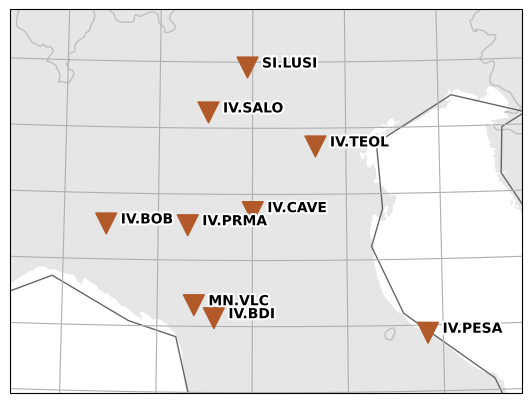

In [4]:
inv.plot(projection="local");

También se puede graficar la respuesta instrumental de un canal específico:

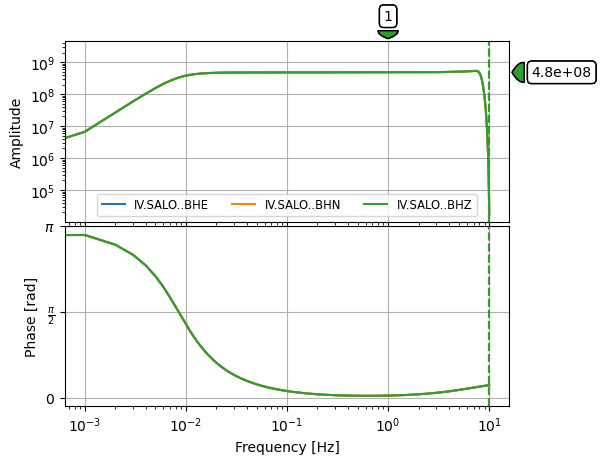

In [5]:
inv.select(network="IV", station="SALO", channel="BH?").plot_response(0.001);

## 3. Extracción de información de un Inventory <a id="información"></a>
Se pueden extraer las coordenadas de un canal específico utilizando el método `get_coordinates`.

Ejemplo:

In [6]:
coords = inv.get_coordinates("IV.SALO..BHZ")
print(coords)

{'latitude': 45.6183, 'longitude': 10.5243, 'elevation': 600.0, 'local_depth': 1.0}


Este método también acepta un argumento de fecha y hora para obtener información en diferentes momentos.

## 4. Selección de datos en un Inventory <a id="4-selección-de-datos"></a>
Puedes seleccionar partes específicas de un Inventory utilizando el método `select`.

Ejemplo de selección de un canal específico:

In [7]:
inv_selected = inv.select(channel="BHZ")
print(inv_selected)

Inventory created at 2015-05-13T23:31:49.000000Z
	Sending institution: SeisComP3 (INGV)
	Contains:
		Networks (2):
			IV, MN
		Stations (7):
			IV.BDI (BAGNI DI LUCCA)
			IV.BOB (BOBBIO)
			IV.PESA (PESARO)
			IV.PRMA (Parma)
			IV.SALO (Salo)
			IV.TEOL (Teolo)
			MN.VLC (Villacollemandina, Italy)
		Channels (7):
			IV.BDI..BHZ, IV.BOB..BHZ, IV.PESA..BHZ, IV.PRMA..BHZ, IV.SALO..BHZ
			IV.TEOL..BHZ, MN.VLC..BHZ


## 5. Escritura de un Inventory <a id="5-escritura"></a>
Para guardar un Inventory en un archivo, se utiliza el método `write`.

Ejemplo de escritura en formato StationXML:

In [8]:
inv_selected.write("temp.xml", format="stationxml")

## 6. Uso de Inventory con datos sísmicos <a id="6-uso-con-datos"></a>
Un Inventory es esencial para eliminar la respuesta instrumental de los datos sísmicos.

Ejemplo de descarga de datos con la respuesta instrumental adjunta:

In [11]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

In [12]:
client = Client("IRIS")
st = client.get_waveforms(network="IU", station="TUC", location="00", channel="HH1", 
                          starttime=UTCDateTime("2019-07-06T03:19:53.04") - 60, 
                          endtime=UTCDateTime("2019-07-06T03:19:53.04") + 60*15, 
                          attach_response=True)
print(st)

1 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples


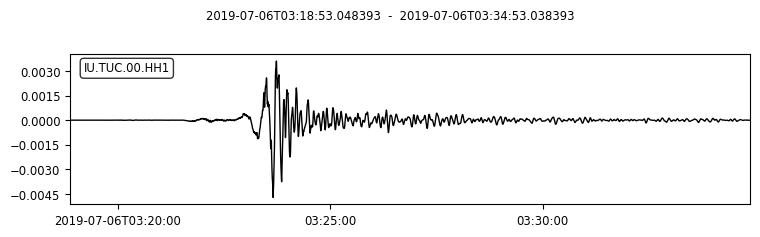

In [14]:
st_rem = st.copy()
st_rem.remove_response(output="VEL")
st_rem.plot();

**Referencias:**

Dybing, S. (2020). ObsPy Tutorial: Full Notebook [Jupyter Notebook]. En ROSES 2020: Research on Seismology. GitHub. https://github.com/roseseismo/roses2020/blob/main/unit01/Obspy_Tutorial_Full_Notebook.ipynb

Krischer, L. & Megies, T.. (2024). Introduction to file formats in ObsPy [Jupyter Notebook with solutions]. In skience2024: Seismology Course Materials. GitHub. https://github.com/heinerigel/skience2024/blob/main/00%20ObsPy%20Intro/01_File_Formats-with_solutions.ipynb